# Лабораторная работа 6. Random Forest



## 1. Импорт библиотек


In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, balanced_accuracy_score,
                             classification_report, confusion_matrix,
                             roc_curve, auc, roc_auc_score)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 120)
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.4.4 | pandas 3.0.2


## 2. Загрузка данных
Размеченная часть соревнования: `X_train` (сырой IMU) и `y_train` (метки). `X_test` не используем — там нет меток, тест выделим сами.

In [2]:
DATA_DIR = "data"
X_raw = pd.read_csv(f"{DATA_DIR}/X_train.csv")
y_raw = pd.read_csv(f"{DATA_DIR}/y_train.csv")
print("X_train:", X_raw.shape, "| y_train:", y_raw.shape)
X_raw.head()

X_train: (487680, 13) | y_train: (3810, 3)


,row_id,series_id,measurement_number,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,linear_acceleration_X,linear_acceleration_Y,linear_acceleration_Z
0,0_0,0,0,-0.75853,-0.63435,-0.10488,-0.10597,0.107650,0.017561,0.000767,-0.74857,2.1030,-9.7532
1,0_1,0,1,-0.75853,-0.63434,-0.10490,-0.10600,0.067851,0.029939,0.003386,0.33995,1.5064,-9.4128
2,0_2,0,2,-0.75853,-0.63435,-0.10492,-0.10597,0.007275,0.028934,-0.005978,-0.26429,1.5922,-8.7267
3,0_3,0,3,-0.75852,-0.63436,-0.10495,-0.10597,-0.013053,0.019448,-0.008974,0.42684,1.0993,-10.0960
4,0_4,0,4,-0.75852,-0.63435,-0.10495,-0.10596,0.005135,0.007652,0.005245,-0.50969,1.4689,-10.4410


In [3]:
y_raw.head()

,series_id,group_id,surface
0,0,13,fine_concrete
1,1,31,concrete
2,2,20,concrete
3,3,31,concrete
4,4,22,soft_tiles


In [4]:
SENSOR_COLS = [c for c in X_raw.columns
               if c not in ("row_id", "series_id", "measurement_number")]
print("Число серий            :", X_raw["series_id"].nunique())
print("Измерений в серии       :", X_raw.groupby("series_id").size().unique())
print("Сенсорных каналов      :", len(SENSOR_COLS), "->", SENSOR_COLS)
print("Классов поверхности    :", y_raw["surface"].nunique())
print("Пропуски X / y         :", int(X_raw.isna().sum().sum()),
      "/", int(y_raw.isna().sum().sum()))

Число серий            : 3810
Измерений в серии       : [128]
Сенсорных каналов      : 10 -> ['orientation_X', 'orientation_Y', 'orientation_Z', 'orientation_W', 'angular_velocity_X', 'angular_velocity_Y', 'angular_velocity_Z', 'linear_acceleration_X', 'linear_acceleration_Y', 'linear_acceleration_Z']
Классов поверхности    : 9
Пропуски X / y         : 0 / 0


## 3. Разведочный анализ

### 3.1. Распределение классов
Сильный дисбаланс (≈779 против 21). Учитываем стратификацией, `class_weight="balanced"` и macro-усреднением метрик.

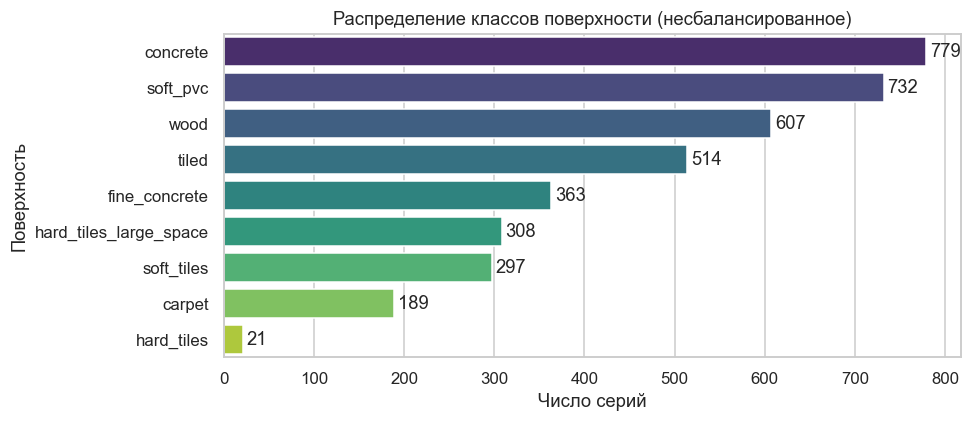

Дисбаланс max/min = 37.1 раз


In [5]:
class_counts = y_raw["surface"].value_counts()
plt.figure(figsize=(9, 4))
sns.barplot(x=class_counts.values, y=class_counts.index,
            hue=class_counts.index, palette="viridis", legend=False)
for i, v in enumerate(class_counts.values):
    plt.text(v + 4, i, str(v), va="center")
plt.title("Распределение классов поверхности (несбалансированное)")
plt.xlabel("Число серий"); plt.ylabel("Поверхность")
plt.tight_layout(); plt.show()
print("Дисбаланс max/min =", round(class_counts.max()/class_counts.min(), 1), "раз")

### 3.2. Пример сигналов
Сырые каналы одной серии — это временные ряды 128×10; для дерева их нужно свернуть в признаки.

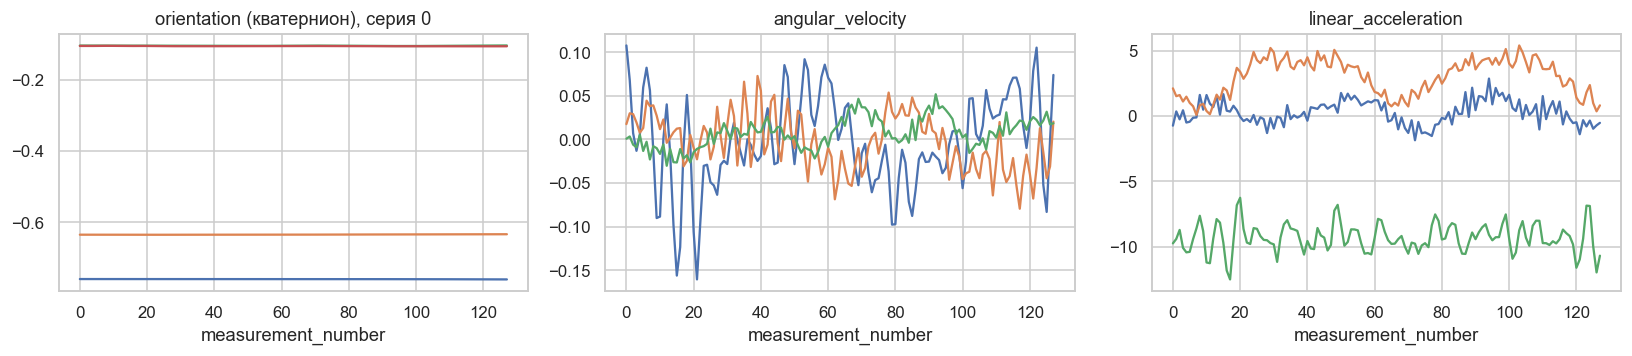

In [6]:
sid = 0
one = X_raw[X_raw["series_id"] == sid]
fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
ax[0].plot(one[["orientation_X", "orientation_Y", "orientation_Z", "orientation_W"]].values)
ax[0].set_title(f"orientation (кватернион), серия {sid}")
ax[1].plot(one[["angular_velocity_X", "angular_velocity_Y", "angular_velocity_Z"]].values)
ax[1].set_title("angular_velocity")
ax[2].plot(one[["linear_acceleration_X", "linear_acceleration_Y", "linear_acceleration_Z"]].values)
ax[2].set_title("linear_acceleration")
for a in ax: a.set_xlabel("measurement_number")
plt.tight_layout(); plt.show()

## 4. Формирование признаков
Сворачиваем ряд каждой серии в агрегаты `mean/std/min/max/median/range/mean_abs_change` по 10 исходным и 5 производным каналам (модули угловой скорости и ускорения, углы Эйлера) — всего 105 признаков. Затем собираем `X`, `y` и проверяем отсутствие пропусков.

In [7]:
def add_derived(df):
    df = df.copy()
    df["ang_vel_mag"] = np.sqrt(df.angular_velocity_X**2 + df.angular_velocity_Y**2
                                + df.angular_velocity_Z**2)
    df["lin_acc_mag"] = np.sqrt(df.linear_acceleration_X**2 + df.linear_acceleration_Y**2
                                + df.linear_acceleration_Z**2)
    x, y, z, w = df.orientation_X, df.orientation_Y, df.orientation_Z, df.orientation_W
    n = np.sqrt(x*x + y*y + z*z + w*w)
    x, y, z, w = x/n, y/n, z/n, w/n
    df["euler_roll"]  = np.arctan2(2*(w*x + y*z), 1 - 2*(x*x + y*y))
    df["euler_pitch"] = np.arcsin(np.clip(2*(w*y - z*x), -1.0, 1.0))
    df["euler_yaw"]   = np.arctan2(2*(w*z + x*y), 1 - 2*(y*y + z*z))
    return df


def featurize(df):
    df = add_derived(df)
    channels = [c for c in df.columns
                if c not in ("row_id", "series_id", "measurement_number")]
    g = df.groupby("series_id")[channels]
    stats = g.agg(["mean", "std", "min", "max", "median"])
    stats.columns = [f"{c}_{s}" for c, s in stats.columns]
    rng = g.max() - g.min()
    rng.columns = [f"{c}_range" for c in rng.columns]
    ds = df.sort_values(["series_id", "measurement_number"])
    mac = ds.groupby("series_id")[channels].diff().abs().groupby(ds["series_id"]).mean()
    mac.columns = [f"{c}_mean_abs_change" for c in mac.columns]
    return pd.concat([stats, rng, mac], axis=1)


features = featurize(X_raw)
print("Матрица признаков:", features.shape,
      "→ серий:", features.shape[0], "| признаков:", features.shape[1])
features.iloc[:5, :6]

Матрица признаков: (3810, 105) → серий: 3810 | признаков: 105


,orientation_X_mean,orientation_X_std,orientation_X_min,orientation_X_max,orientation_X_median,orientation_Y_mean
series_id,,,,,,
0,-0.758666,0.000363,-0.75953,-0.75822,-0.758530,-0.634008
1,-0.958606,0.000151,-0.95896,-0.95837,-0.958595,0.241867
2,-0.512057,0.001377,-0.51434,-0.50944,-0.512035,-0.846171
3,-0.939169,0.000227,-0.93968,-0.93884,-0.939170,0.310140
4,-0.891301,0.002955,-0.89689,-0.88673,-0.890940,0.428144


In [8]:
data = features.join(y_raw.set_index("series_id")["surface"])
feature_names = list(features.columns)
X = data[feature_names].to_numpy(float)
y = data["surface"].to_numpy()
classes = np.array(sorted(np.unique(y)))
print("X:", X.shape, "| y:", y.shape)
print("NaN:", int(np.isnan(X).sum()), "| inf:", int(np.isinf(X).sum()))
print("Классы:", list(classes))

X: (3810, 105) | y: (3810,)
NaN: 0 | inf: 0
Классы: [np.str_('carpet'), np.str_('concrete'), np.str_('fine_concrete'), np.str_('hard_tiles'), np.str_('hard_tiles_large_space'), np.str_('soft_pvc'), np.str_('soft_tiles'), np.str_('tiled'), np.str_('wood')]


## 5. Разбиение на train / test
Стратифицированный сплит 75/25 — сохраняет доли классов (важно для редкого `hard_tiles`). Полностью честная оценка требовала бы `GroupKFold` по `group_id`.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)
pd.DataFrame({"train": pd.Series(y_train).value_counts(),
              "test":  pd.Series(y_test).value_counts()}).fillna(0).astype(int)

Train: (2857, 105) | Test: (953, 105)


,train,test
concrete,584,195
soft_pvc,549,183
wood,455,152
tiled,385,129
fine_concrete,272,91
hard_tiles_large_space,231,77
soft_tiles,223,74
carpet,142,47
hard_tiles,16,5


## 6. Собственная реализация Random Forest
**CART** (`DecisionTreeCART`): бинарные разбиения по критерию Джини, лист хранит распределение классов (вероятности для ROC). Разбиения бинарные, но дерево растёт несбалансированно (ветви разной длины); дисбаланс учтён весами классов в Джини.

**Random Forest** (`RandomForestScratch`): бутстрэп-выборка + случайные `√p` признаков в узле + усреднение вероятностей деревьев.

In [10]:
class _Node:
    __slots__ = ("feature", "threshold", "left", "right", "proba")
    def __init__(self):
        self.feature = None; self.threshold = None
        self.left = None; self.right = None; self.proba = None


class DecisionTreeCART:
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1,
                 max_features=None, n_classes=None, rng=None):
        self.max_depth = 10**9 if max_depth is None else max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.K = n_classes
        self.rng = rng if rng is not None else np.random.default_rng()

    def fit(self, X, y, w):
        p = X.shape[1]
        if self.max_features is None:        self.mtry_ = p
        elif self.max_features == "sqrt":    self.mtry_ = max(1, int(np.sqrt(p)))
        else:                                self.mtry_ = min(p, int(self.max_features))
        self.n_features_ = p
        self.importances_ = np.zeros(p)
        self.root_ = self._build(X, y, w, 0)
        s = self.importances_.sum()
        if s > 0: self.importances_ /= s
        return self

    def _leaf(self, y, w):
        node = _Node()
        cnt = np.bincount(y, weights=w, minlength=self.K)
        s = cnt.sum()
        node.proba = cnt/s if s > 0 else np.full(self.K, 1.0/self.K)
        return node

    def _build(self, X, y, w, depth):
        n = X.shape[0]
        if depth >= self.max_depth or n < self.min_samples_split or (y == y[0]).all():
            return self._leaf(y, w)
        feat, thr, gain = self._best_split(X, y, w)
        if feat is None:
            return self._leaf(y, w)
        mask = X[:, feat] <= thr
        if mask.sum() < self.min_samples_leaf or (~mask).sum() < self.min_samples_leaf:
            return self._leaf(y, w)
        self.importances_[feat] += w.sum() * gain
        node = _Node(); node.feature = feat; node.threshold = thr
        node.left  = self._build(X[mask],  y[mask],  w[mask],  depth+1)
        node.right = self._build(X[~mask], y[~mask], w[~mask], depth+1)
        return node

    def _best_split(self, X, y, w):
        feats = self.rng.choice(self.n_features_, size=self.mtry_, replace=False)
        parent_cnt = np.bincount(y, weights=w, minlength=self.K)
        W = parent_cnt.sum()
        parent_gini = 1.0 - ((parent_cnt/W)**2).sum()
        Yoh = np.eye(self.K)[y] * w[:, None]
        best_gain, best_feat, best_thr = 1e-12, None, None
        for f in feats:
            xf = X[:, f]
            order = np.argsort(xf, kind="quicksort")
            xs = xf[order]
            cumL = np.cumsum(Yoh[order], axis=0)[:-1]
            wL = cumL.sum(axis=1); wR = W - wL
            valid = xs[:-1] != xs[1:]
            giniL = 1.0 - (cumL**2).sum(axis=1)/np.where(wL > 0, wL, 1)**2
            cumR = parent_cnt - cumL
            giniR = 1.0 - (cumR**2).sum(axis=1)/np.where(wR > 0, wR, 1)**2
            gain = parent_gini - (wL*giniL + wR*giniR)/W
            gain = np.where(valid, gain, -1.0)
            i = int(np.argmax(gain))
            if gain[i] > best_gain:
                best_gain, best_feat = gain[i], int(f)
                best_thr = (xs[i] + xs[i+1])/2.0
        return best_feat, best_thr, best_gain

    def predict_proba(self, X):
        out = np.empty((X.shape[0], self.K))
        self._fill(self.root_, X, np.arange(X.shape[0]), out)
        return out

    def _fill(self, node, X, idx, out):
        if node.feature is None:
            out[idx] = node.proba; return
        m = X[idx, node.feature] <= node.threshold
        self._fill(node.left,  X, idx[m],  out)
        self._fill(node.right, X, idx[~m], out)

    def depth(self):
        def d(nd): return 0 if nd.feature is None else 1 + max(d(nd.left), d(nd.right))
        return d(self.root_)

    def leaf_depths(self):
        res = []
        def rec(nd, d):
            if nd.feature is None: res.append(d)
            else: rec(nd.left, d+1); rec(nd.right, d+1)
        rec(self.root_, 0); return res

In [11]:
class RandomForestScratch:
    def __init__(self, n_estimators=100, max_depth=None, max_features="sqrt",
                 min_samples_leaf=1, min_samples_split=2, bootstrap=True,
                 class_weight=None, random_state=0):
        self.n_estimators = n_estimators; self.max_depth = max_depth
        self.max_features = max_features; self.min_samples_leaf = min_samples_leaf
        self.min_samples_split = min_samples_split; self.bootstrap = bootstrap
        self.class_weight = class_weight; self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X, float)
        self.classes_ = np.unique(y)
        self.K = len(self.classes_)
        idxmap = {c: i for i, c in enumerate(self.classes_)}
        yi = np.array([idxmap[v] for v in y])
        n = len(yi)
        counts = np.bincount(yi, minlength=self.K)
        cw = n/(self.K*counts) if self.class_weight == "balanced" else np.ones(self.K)
        base_w = cw[yi]
        seeds = np.random.SeedSequence(self.random_state).spawn(self.n_estimators)
        self.trees_, self.tree_depths_ = [], []
        imp = np.zeros(X.shape[1])
        for t in range(self.n_estimators):
            rng = np.random.default_rng(seeds[t])
            idx = rng.integers(0, n, n) if self.bootstrap else np.arange(n)
            tree = DecisionTreeCART(self.max_depth, self.min_samples_split,
                                    self.min_samples_leaf, self.max_features,
                                    self.K, rng)
            tree.fit(X[idx], yi[idx], base_w[idx])
            self.trees_.append(tree)
            self.tree_depths_.append(tree.depth())
            imp += tree.importances_
        self.feature_importances_ = imp/self.n_estimators
        return self

    def predict_proba(self, X):
        X = np.asarray(X, float)
        P = np.zeros((X.shape[0], self.K))
        for tr in self.trees_:
            P += tr.predict_proba(X)
        return P/len(self.trees_)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

### 6.1. Проверка реализации
Быстрый прогон 15 деревьев: модель обучается, важности признаков нормированы к 1.

In [12]:
t0 = time.time()
_sanity = RandomForestScratch(n_estimators=15, max_depth=12, max_features="sqrt",
                              class_weight="balanced", random_state=RANDOM_STATE)
_sanity.fit(X_train, y_train)
_acc = accuracy_score(y_test, _sanity.predict(X_test))
print(f"Лес из 15 деревьев обучен за {time.time()-t0:.1f}s, accuracy на тесте = {_acc:.3f}")
print(f"Сумма важностей признаков = {_sanity.feature_importances_.sum():.3f}")

Лес из 15 деревьев обучен за 1.3s, accuracy на тесте = 0.890
Сумма важностей признаков = 1.000


## 7. Обоснование ограничения глубины

### 7.1. Без ограничения дерево несбалансированно и переобучается
Глубины листьев одного дерева сильно разнятся (несбалансированность). Лес без ограничения почти идеально запоминает train (accuracy≈1.0) — переобучение.

Одно дерево без ограничения: глубина=18, листьев=434
Глубины листьев: min=4, max=18, mean=10.9 (ветви разной длины)


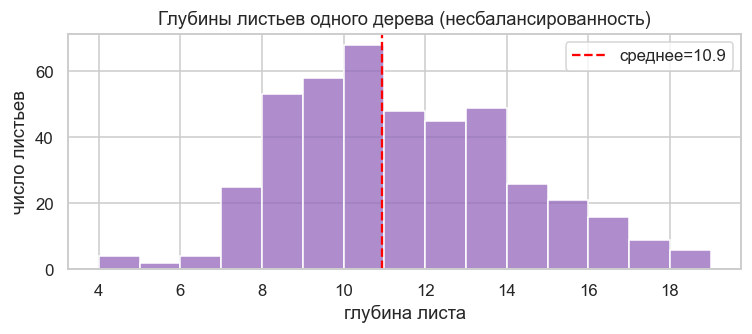

In [13]:
yi_full = np.unique(y_train, return_inverse=True)[1]
demo_tree = DecisionTreeCART(max_depth=None, max_features="sqrt",
                             n_classes=len(classes), rng=np.random.default_rng(0))
demo_tree.fit(X_train, yi_full, np.ones(len(yi_full)))
ld = np.array(demo_tree.leaf_depths())
print(f"Одно дерево без ограничения: глубина={demo_tree.depth()}, листьев={len(ld)}")
print(f"Глубины листьев: min={ld.min()}, max={ld.max()}, mean={ld.mean():.1f} (ветви разной длины)")

plt.figure(figsize=(7, 3.2))
sns.histplot(ld, bins=range(ld.min(), ld.max()+2), color="tab:purple")
plt.axvline(ld.mean(), color="red", ls="--", label=f"среднее={ld.mean():.1f}")
plt.title("Глубины листьев одного дерева (несбалансированность)")
plt.xlabel("глубина листа"); plt.ylabel("число листьев"); plt.legend()
plt.tight_layout(); plt.show()

In [14]:
rf_full = RandomForestScratch(n_estimators=40, max_depth=None, max_features="sqrt",
                              class_weight="balanced", random_state=RANDOM_STATE)
rf_full.fit(X_train, y_train)
acc_tr = accuracy_score(y_train, rf_full.predict(X_train))
acc_te = accuracy_score(y_test, rf_full.predict(X_test))
print("Лес БЕЗ ограничения глубины (40 деревьев):")
print(f"  глубина деревьев: mean={np.mean(rf_full.tree_depths_):.1f}, max={max(rf_full.tree_depths_)}")
print(f"  accuracy train = {acc_tr:.3f}")
print(f"  accuracy test  = {acc_te:.3f}  (разрыв с train = переобучение)")

Лес БЕЗ ограничения глубины (40 деревьев):
  глубина деревьев: mean=18.1, max=23
  accuracy train = 1.000
  accuracy test  = 0.898  (разрыв с train = переобучение)


### 7.2. Кривая валидации по `max_depth`
3-фолдовая кросс-валидация (своя реализация): train→1.0, CV выходит на плато. По правилу 1-SE берём наименьшую глубину в пределах 1σ от лучшей.

In [15]:
def cv_depth_curve(X, y, depths, n_estimators=25, n_splits=3, seed=RANDOM_STATE):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    tr_scores = np.zeros((len(depths), n_splits))
    va_scores = np.zeros((len(depths), n_splits))
    for di, d in enumerate(depths):
        for fi, (tr, va) in enumerate(skf.split(X, y)):
            rf = RandomForestScratch(n_estimators=n_estimators, max_depth=d,
                                     max_features="sqrt", class_weight="balanced",
                                     random_state=seed + fi)
            rf.fit(X[tr], y[tr])
            tr_scores[di, fi] = balanced_accuracy_score(y[tr], rf.predict(X[tr]))
            va_scores[di, fi] = balanced_accuracy_score(y[va], rf.predict(X[va]))
    return tr_scores, va_scores


depth_range = [2, 3, 5, 7, 9, 12, 16, 20]
t0 = time.time()
tr_sc, va_sc = cv_depth_curve(X_train, y_train, depth_range)
print(f"Кривая валидации посчитана за {time.time()-t0:.0f}s")

train_mean, train_std = tr_sc.mean(1), tr_sc.std(1)
val_mean,   val_std   = va_sc.mean(1), va_sc.std(1)
best_i = int(np.argmax(val_mean))
se = val_std/np.sqrt(tr_sc.shape[1])
threshold = val_mean[best_i] - se[best_i]
chosen_depth = next(d for d, m in zip(depth_range, val_mean) if m >= threshold)
print(f"Максимум CV при max_depth={depth_range[best_i]} (balanced_acc={val_mean[best_i]:.3f})")
print(f"Правило 1-SE -> max_depth={chosen_depth} (balanced_acc={val_mean[depth_range.index(chosen_depth)]:.3f})")

Кривая валидации посчитана за 24s
Максимум CV при max_depth=20 (balanced_acc=0.823)
Правило 1-SE -> max_depth=16 (balanced_acc=0.820)


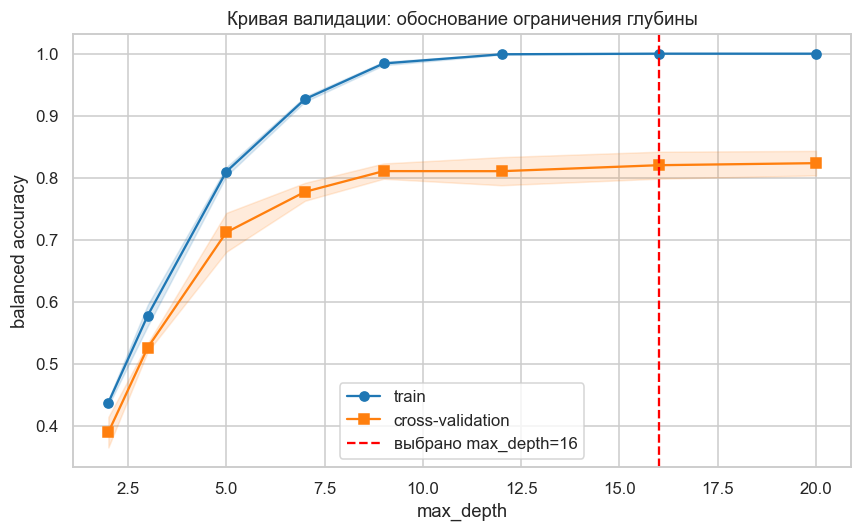

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(depth_range, train_mean, "o-", color="tab:blue", label="train")
plt.fill_between(depth_range, train_mean-train_std, train_mean+train_std,
                 alpha=0.15, color="tab:blue")
plt.plot(depth_range, val_mean, "s-", color="tab:orange", label="cross-validation")
plt.fill_between(depth_range, val_mean-val_std, val_mean+val_std,
                 alpha=0.15, color="tab:orange")
plt.axvline(chosen_depth, ls="--", color="red", label=f"выбрано max_depth={chosen_depth}")
plt.xlabel("max_depth"); plt.ylabel("balanced accuracy")
plt.title("Кривая валидации: обоснование ограничения глубины")
plt.legend(); plt.tight_layout(); plt.show()

Ниже выбранной глубины — недообучение; выше — растёт только разрыв train–CV (переобучение). Поэтому ограничиваем глубину выбранным значением.

## 8. Обучение финальной модели
Лес: выбранный `max_depth`, 120 деревьев, `max_features="sqrt"`, `class_weight="balanced"`.

In [17]:
t0 = time.time()
rf = RandomForestScratch(n_estimators=120, max_depth=chosen_depth,
                         max_features="sqrt", class_weight="balanced",
                         random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
print(f"Обучено за {time.time()-t0:.1f}s. max_depth={chosen_depth}; "
      f"глубина деревьев: mean={np.mean(rf.tree_depths_):.1f}, max={max(rf.tree_depths_)}")

Обучено за 11.5s. max_depth=16; глубина деревьев: mean=16.0, max=16


## 9. Метрики качества
accuracy + precision / recall / F1 в macro (равноправно по классам) и weighted (по частоте).

In [18]:
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
rows = []
for avg in ("macro", "weighted"):
    rows.append({"average": avg,
                 "precision": precision_score(y_test, y_pred, average=avg, zero_division=0),
                 "recall":    recall_score(y_test, y_pred, average=avg, zero_division=0),
                 "f1":        f1_score(y_test, y_pred, average=avg, zero_division=0)})
print(f"Accuracy: {acc:.3f}\n")
print(pd.DataFrame(rows).set_index("average").round(3))

Accuracy: 0.908

          precision  recall     f1
average                           
macro         0.903   0.894  0.898
weighted      0.909   0.908  0.908


### 9.1. Отчёт по классам

In [19]:
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

                        precision    recall  f1-score   support

                carpet      0.952     0.851     0.899        47
              concrete      0.877     0.918     0.897       195
         fine_concrete      0.920     0.890     0.905        91
            hard_tiles      0.800     0.800     0.800         5
hard_tiles_large_space      0.972     0.909     0.940        77
              soft_pvc      0.930     0.940     0.935       183
            soft_tiles      0.880     0.986     0.930        74
                 tiled      0.921     0.899     0.910       129
                  wood      0.878     0.855     0.867       152

              accuracy                          0.908       953
             macro avg      0.903     0.894     0.898       953
          weighted avg      0.909     0.908     0.908       953



### 9.2. Матрица ошибок

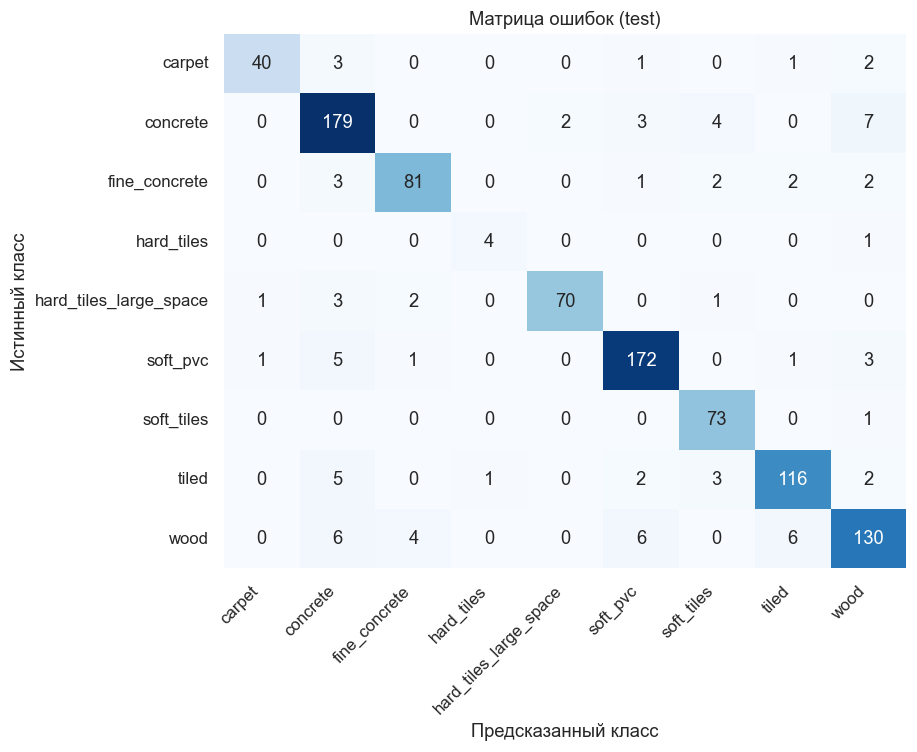

In [20]:
cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(8.5, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes, cbar=False)
plt.xlabel("Предсказанный класс"); plt.ylabel("Истинный класс")
plt.title("Матрица ошибок (test)")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

## 10. ROC-кривая
One-vs-rest по 9 классам (вероятности нашего леса) + micro/macro усреднение и AUC.

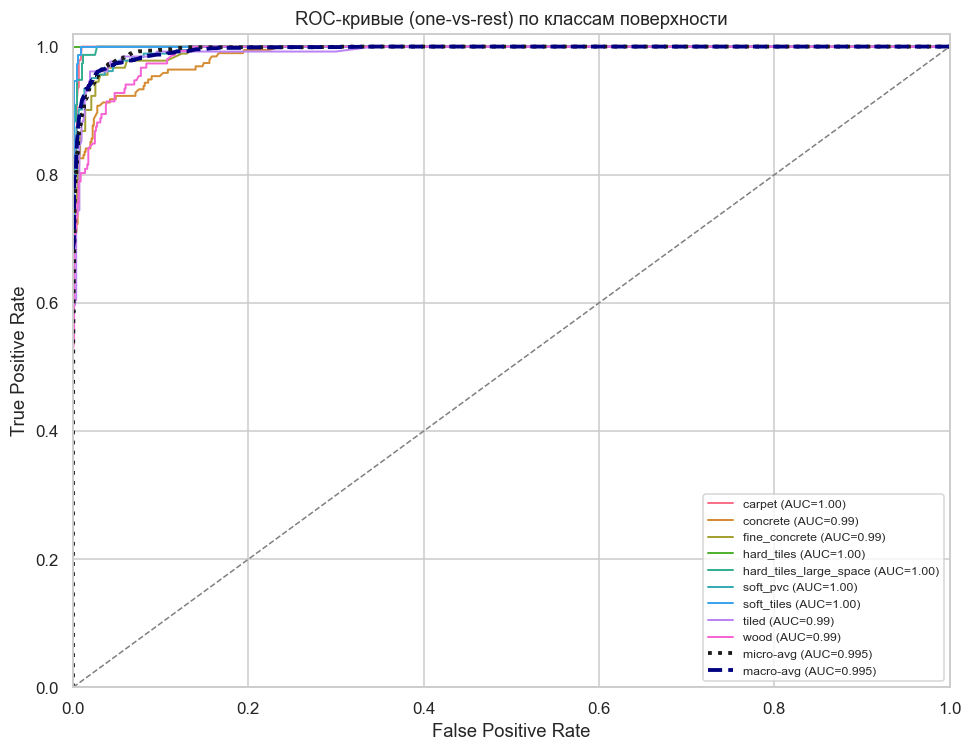

ROC AUC (macro, OvR)   : 0.995
ROC AUC (weighted, OvR): 0.993


In [21]:
y_test_bin = label_binarize(y_test, classes=classes)
y_score = rf.predict_proba(X_test)
n_classes = len(classes)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(all_fpr, mean_tpr)

palette = sns.color_palette("husl", n_classes)
plt.figure(figsize=(9, 7))
for i, c in enumerate(classes):
    plt.plot(fpr[i], tpr[i], color=palette[i], lw=1.3, label=f"{c} (AUC={roc_auc[i]:.2f})")
plt.plot(fpr["micro"], tpr["micro"], "k:", lw=2.5, label=f"micro-avg (AUC={roc_auc['micro']:.3f})")
plt.plot(fpr["macro"], tpr["macro"], color="navy", ls="--", lw=2.5, label=f"macro-avg (AUC={roc_auc['macro']:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, ls="--")
plt.xlim(0, 1); plt.ylim(0, 1.02)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC-кривые (one-vs-rest) по классам поверхности")
plt.legend(loc="lower right", fontsize=8); plt.tight_layout(); plt.show()

print("ROC AUC (macro, OvR)   :",
      round(roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr"), 3))
print("ROC AUC (weighted, OvR):",
      round(roc_auc_score(y_test, y_score, average="weighted", multi_class="ovr", labels=classes), 3))

## 11. Важность признаков
Топ-20 по суммарному уменьшению Джини (накапливается в нашей реализации).

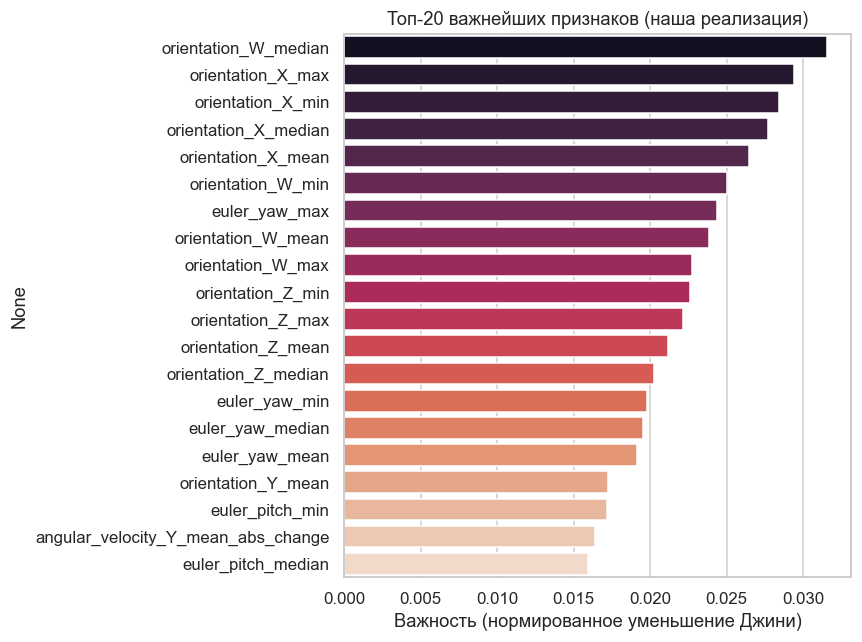

orientation_W_median    0.0316
orientation_X_max       0.0294
orientation_X_min       0.0284
orientation_X_median    0.0277
orientation_X_mean      0.0265
orientation_W_min       0.0250
euler_yaw_max           0.0244
orientation_W_mean      0.0239
orientation_W_max       0.0228
orientation_Z_min       0.0226
dtype: float64

In [22]:
imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
top = imp.head(20)
sns.barplot(x=top.values, y=top.index, hue=top.index, palette="rocket", legend=False)
plt.title("Топ-20 важнейших признаков (наша реализация)")
plt.xlabel("Важность (нормированное уменьшение Джини)")
plt.tight_layout(); plt.show()
imp.head(10).round(4)